In [16]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [2]:
df = pd.read_csv("../HAM10000_Dataset/HAM10000_features_colors.csv")
df

,image_id,dx,age,sex,localization,color_1_R,color_1_G,color_1_B,color_1_proportion,color_2_R,...,color_3_R,color_3_G,color_3_B,color_3_proportion,asym_vert_%,asym_horiz_%,Perimeter,Area,circularity,eccentricity
0,ISIC_0027419,nomel,80.0,male,scalp,219.179990,177.235439,198.679157,0.457572,184.425591,...,207.771385,150.836506,157.093755,0.390716,19.105153,17.450459,1251.785930,85333,0.684332,0.686623
1,ISIC_0025030,nomel,80.0,male,scalp,226.107693,187.273683,205.974215,0.442245,189.566767,...,214.179005,158.707311,160.624952,0.404999,35.036812,16.117057,754.488419,32326,0.713603,0.534008
2,ISIC_0026769,nomel,80.0,male,scalp,198.104553,122.933030,132.345778,0.168120,224.884205,...,217.491455,150.013374,164.787046,0.429084,16.548578,15.708324,1114.560533,72121,0.729565,0.646662
3,ISIC_0025661,nomel,80.0,male,scalp,227.012822,170.157376,192.372925,0.345771,217.576529,...,196.976197,117.661687,125.351988,0.185448,19.936487,28.734881,598.215295,21413,0.751921,0.676903
4,ISIC_0031633,nomel,75.0,male,ear,215.138856,162.599185,184.575606,0.301135,145.233630,...,184.497142,129.514243,139.646944,0.433511,24.592457,17.613228,1274.011327,102934,0.796934,0.418797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,ISIC_0033084,nomel,40.0,male,abdomen,148.506775,101.631723,97.752969,0.213116,214.066087,...,184.334036,138.683070,136.519719,0.290280,15.381048,18.506901,1562.822510,146648,0.754513,0.704614
10011,ISIC_0033550,nomel,40.0,male,abdomen,205.608162,160.438709,161.972693,0.495766,175.788089,...,141.078120,92.865797,88.159177,0.215991,14.037954,11.100383,924.648845,53854,0.791542,0.693115
10012,ISIC_0033536,nomel,40.0,male,abdomen,232.295149,191.089008,191.237413,0.494415,163.062171,...,200.012468,152.132820,146.205180,0.289340,13.481511,13.215853,1129.986940,79049,0.777964,0.712581
10013,ISIC_0032854,nomel,80.0,male,face,198.650101,174.036274,183.928216,0.428142,181.533601,...,192.057606,153.046401,160.976969,0.365636,35.563498,19.522941,1657.449927,137090,0.627097,0.488606


In [3]:
feature_cols = [
    "Area", "Perimeter", "circularity", "eccentricity",
    "color_1_R","color_1_G","color_1_B","color_1_proportion",
    "color_2_R","color_2_G","color_2_B","color_2_proportion",
    "color_3_R","color_3_G","color_3_B","color_3_proportion",
    "asym_vert_%","asym_horiz_%"
]

In [4]:
df["label"] = (df["dx"] == "mel").astype(int)  # 1 = mel, 0 = non-mel
nb_ones = (df["label"] == 1).sum()
nb_ones

np.int64(1113)

In [5]:
#We need to use the same split train/test
IMG_SIZE = (128, 128)

def load_image_for_vgg(img_id):
    path = f"../HAM10000_Dataset/HAM10000/{img_id}.jpg"
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img, dtype=np.float32)
    img = preprocess_input(img)
    return img

X = np.stack([
    load_image_for_vgg(img_id)
    for img_id in tqdm(df["image_id"], desc="Chargement images VGG")
])
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


Chargement images VGG: 100%|██████████| 10015/10015 [02:09<00:00, 77.28it/s]


In [6]:
#Prediction of the model on HAM10000Dataset

model = load_model("AI_Model/cnn_vgg16_transfer_melanome.keras")
train_pred = model.predict(X_train, batch_size=32, verbose=1)
test_pred = model.predict(X_test, batch_size=32, verbose=1)

220/220 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step


In [9]:
#MIA method
EPS = 1e-8 #Avoid log(0)

def to_prob_1(pred):
    pred = np.asarray(pred)

    if pred.ndim == 1:
        p1 = pred
    elif pred.ndim == 2 and pred.shape[1] == 1:
        p1 = pred[:, 0]
    elif pred.ndim == 2 and pred.shape[1] == 2:
        p1 = pred[:, 1]
    else:
        raise ValueError(f"Error on Shape prediction: {pred.shape}")

    p1 = np.clip(p1, EPS, 1 - EPS)
    return p1

def build_mia_features(pred, y_true, member_flag):
    p1 = to_prob_1(pred)
    y_true = np.asarray(y_true).astype(int)

    p_true = np.where(y_true == 1, p1, 1 - p1)
    p_other = 1 - p_true

    loss = -(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))
    entropy = -(p1 * np.log(p1) + (1 - p1) * np.log(1 - p1))
    margin = np.abs(p1 - 0.5) * 2

    return pd.DataFrame({
        "member": member_flag,
        "y_true": y_true,
        "p1": p1,
        "p_true": p_true,
        "loss": loss,
        "entropy": entropy,
        "margin": margin
    })

mia_train = build_mia_features(train_pred, y_train, member_flag=1)
mia_test = build_mia_features(test_pred, y_test, member_flag=0)

mia_df = pd.concat([mia_train, mia_test], axis=0, ignore_index=True)
mia_df

,member,y_true,p1,p_true,loss,entropy,margin
0,1,0,0.012192,0.987808,0.012267,0.065848,0.975616
1,1,0,0.000379,0.999621,0.000379,0.003366,0.999242
2,1,0,0.002415,0.997585,0.002418,0.016963,0.995171
3,1,0,0.001219,0.998781,0.001220,0.009400,0.997561
4,1,0,0.003273,0.996727,0.003278,0.021995,0.993454
...,...,...,...,...,...,...,...
8508,0,0,0.012926,0.987074,0.013010,0.069052,0.974148
8509,0,0,0.059556,0.940444,0.061403,0.225744,0.880888
8510,0,0,0.162981,0.837019,0.177909,0.444581,0.674037
8511,0,0,0.010832,0.989168,0.010891,0.059791,0.978336


In [10]:
#group comparison
mia_df.groupby("member")[["p_true", "loss", "entropy", "margin"]].mean()

,p_true,loss,entropy,margin
member,,,,
0,0.863258,0.253783,0.210315,0.823199
1,0.908289,0.125118,0.191693,0.845158


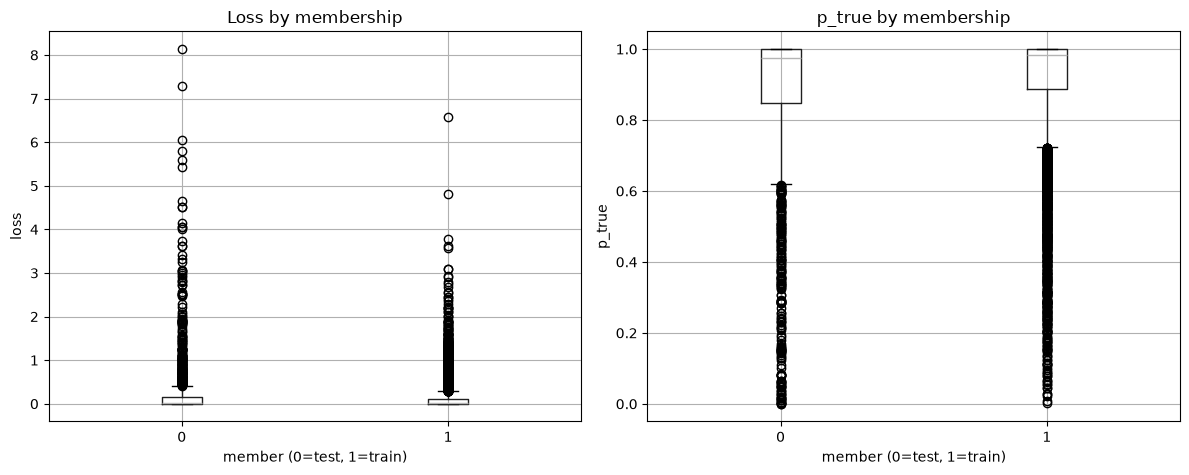

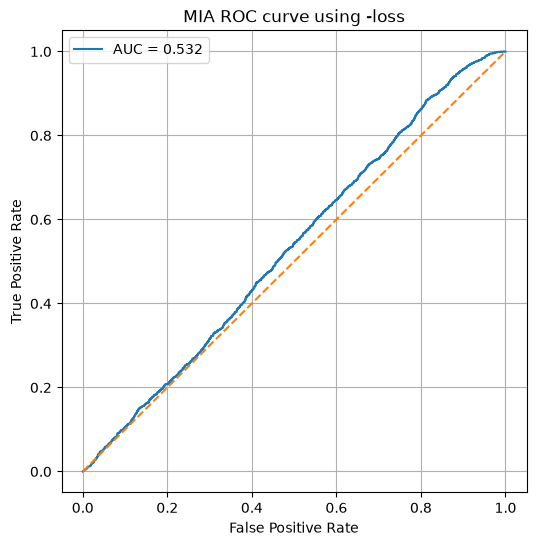

Attack AUC: 0.5322


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mia_df.boxplot(column="loss", by="member", ax=axes[0])
axes[0].set_title("Loss by membership")
axes[0].set_xlabel("member (0=test, 1=train)")
axes[0].set_ylabel("loss")

mia_df.boxplot(column="p_true", by="member", ax=axes[1])
axes[1].set_title("p_true by membership")
axes[1].set_xlabel("member (0=test, 1=train)")
axes[1].set_ylabel("p_true")

plt.suptitle("")
plt.tight_layout()
plt.show()


# 2) ROC curve avec score = -loss
y_attack = mia_df["member"].values
attack_score = -mia_df["loss"].values

auc = roc_auc_score(y_attack, attack_score)
fpr, tpr, thresholds = roc_curve(y_attack, attack_score)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MIA ROC curve using -loss")
plt.legend()
plt.grid(True)
plt.show()

print("Attack AUC:", round(auc, 4))

Attack AUC: 0.5215


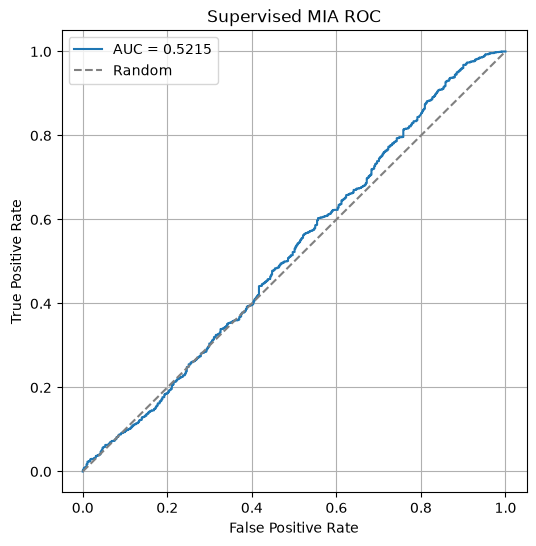

In [17]:
# 1) Features d'attaque
attack_features = ["p_true", "loss", "entropy", "margin"]

X_attack = mia_df[attack_features].copy()
y_attack = mia_df["member"].astype(int).values

# 2) Split train/test pour l'attaque
X_att_train, X_att_test, y_att_train, y_att_test = train_test_split(
    X_attack,
    y_attack,
    test_size=0.3,
    random_state=42,
    stratify=y_attack
)

# 3) Modèle d'attaque
attack_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

attack_model.fit(X_att_train, y_att_train)

# 4) Scores
attack_probs = attack_model.predict_proba(X_att_test)[:, 1]
attack_auc = roc_auc_score(y_att_test, attack_probs)

print("Attack AUC:", round(attack_auc, 4))

# 5) ROC
fpr, tpr, thresholds = roc_curve(y_att_test, attack_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {attack_auc:.4f}")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Supervised MIA ROC")
plt.legend()
plt.grid(True)
plt.show()